In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [112]:
data = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\Documents\Internship Work\Sample - Superstore.csv",encoding="latin1")

In [113]:
def fix_year(year):
    if(len(year)<4):
        year = '20' + year
    return year

In [114]:
def fix_month(month):
    if(len(month)<2):
        month = '0' + month
    return month

In [115]:
data['Order Date'] = data['Order Date'].str.replace('-','/')
data['Month'] = data['Order Date'].str.split('/').str[0]
data['Month'] = data['Month'].apply(fix_month)
data['Month'] = data['Month'].apply(int)
data['Year'] = data['Order Date'].str.split('/').str[2]
data['Year'] = data['Year'].apply(fix_year)
data['Year'] = data['Year'].apply(int)
data['Date'] = data['Month'].astype(str) + '-' + data['Year'].astype(str)
tablep = pd.get_dummies(data,columns = ['Region','Segment','Sub-Category'])
tablef = data[['Date','Ship Mode','Year','Segment','Region','Sub-Category','Quantity','Discount','Sales']]

pd.set_option('display.max_rows',10)
print(tablef)
print(tablef.isna().any().any())
print(tablep)

print(tablep.columns.tolist())
print(tablep.isna().any().any())

         Date       Ship Mode  Year    Segment Region Sub-Category  Quantity  \
0     11-2016    Second Class  2016   Consumer  South    Bookcases         2   
1     11-2016    Second Class  2016   Consumer  South       Chairs         3   
2      6-2016    Second Class  2016  Corporate   West       Labels         2   
3     10-2015  Standard Class  2015   Consumer  South       Tables         5   
4     10-2015  Standard Class  2015   Consumer  South      Storage         2   
...       ...             ...   ...        ...    ...          ...       ...   
9989   1-2014    Second Class  2014   Consumer  South  Furnishings         3   
9990   2-2017  Standard Class  2017   Consumer   West  Furnishings         2   
9991   2-2017  Standard Class  2017   Consumer   West       Phones         2   
9992   2-2017  Standard Class  2017   Consumer   West        Paper         4   
9993   5-2017    Second Class  2017   Consumer   West   Appliances         2   

      Discount     Sales  
0         0.

In [116]:
x = tablep[['Quantity', 'Discount', 'Month','Year', 'Region_Central', 'Region_East', 'Region_South', 'Region_West', 'Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office', 'Sub-Category_Accessories', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables']]
y = tablep['Sales']
x = x.astype(int)
print(x.dtypes)

Quantity                 int64
Discount                 int64
Month                    int64
Year                     int64
Region_Central           int64
                         ...  
Sub-Category_Paper       int64
Sub-Category_Phones      int64
Sub-Category_Storage     int64
Sub-Category_Supplies    int64
Sub-Category_Tables      int64
Length: 28, dtype: object


In [117]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state=42)
regr = LinearRegression()
regr.fit(x_train,y_train)
y_pred = regr.predict(x_test)
print(regr.score(x_test,y_test))

0.16868973778543028


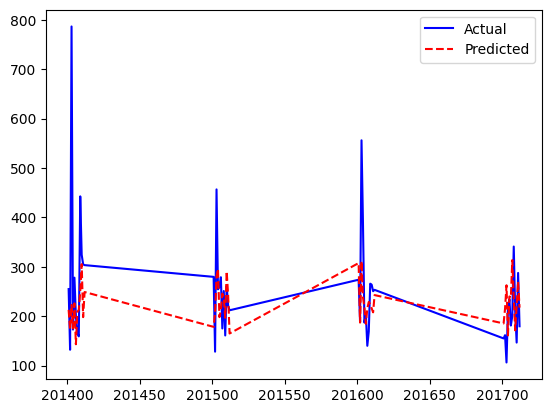

In [120]:

x_test['Date'] = x_test['Year']*100 + x_test['Month']
x_train['Date'] = x_train['Year']*100 + x_train['Month']
"""
x_test = x_test.sort_values('Date')
x_train = x_train.sort_values('Date')
"""
results = pd.DataFrame({
    'Date': x_test['Date'],
    'Actual': y_test.values,
    'Predicted': y_pred
})

results = results.groupby('Date').mean().reset_index()

plt.plot(results.Date, results.Actual, label='Actual', color='blue', linestyle='-')
plt.plot(results.Date, results.Predicted, label='Predicted', color='red', linestyle='--')
plt.legend()
plt.show()